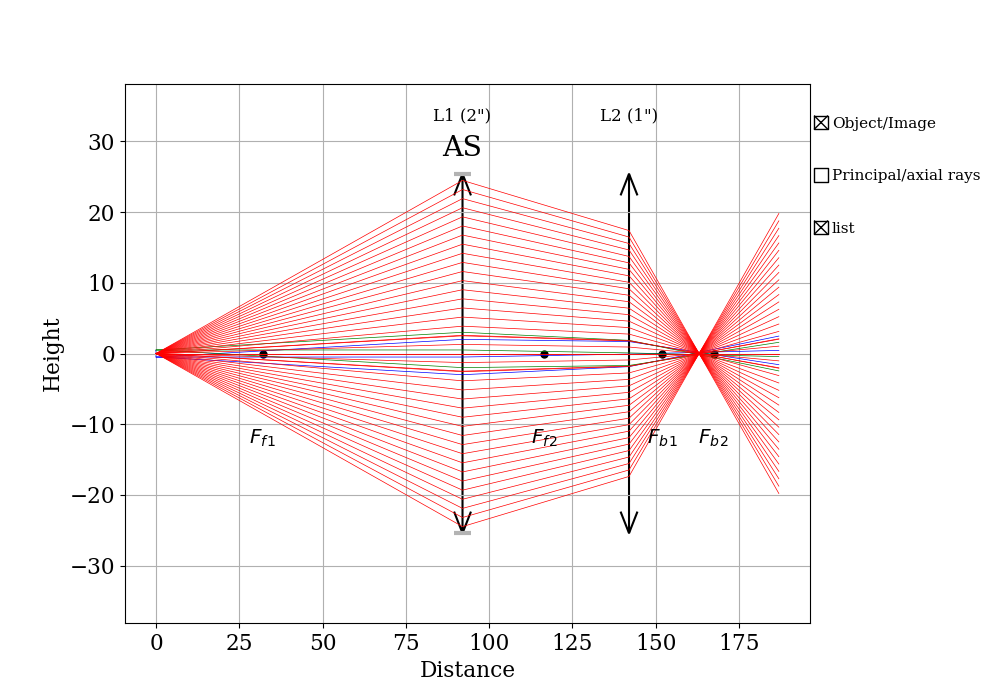

In [8]:
from raytracing import *
import matplotlib.pyplot as plt
%matplotlib widget
plt.rc('axes', grid=True)
plt.rc('font', family='serif')
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('axes', titlesize=16, labelsize=16)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=18)

#from Zho, fig 3.7

path = ImagingPath()
path.objectHeight = 1.0  # mm, atom cloud size
path.append(Space(d=92))
path.append(Lens(f=60,   diameter=50.8, label="L1 (2\")"))
path.append(Space(d=50))
path.append(Lens(f=25.4, label="L2 (1\")"))
path.append(Space(d=45))

fan = [Ray(y=0, theta=t) for t in np.linspace(-0.35, 0.35, 51)]

path.display(raysList=[fan])

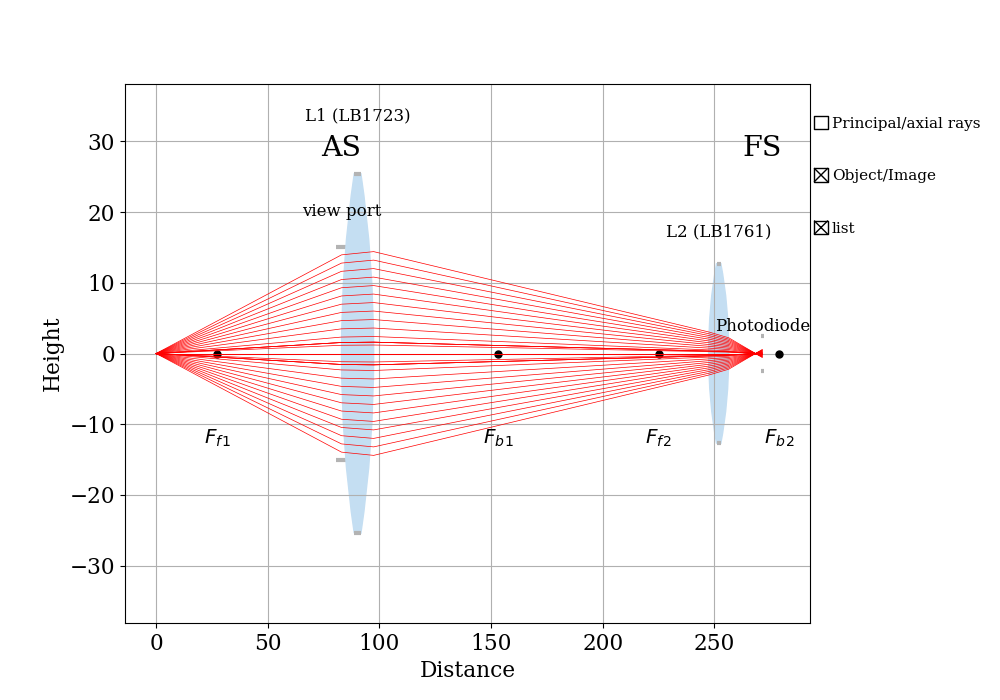

In [12]:
# --- Glass ---
n_bk7_852 = 1.50980


# --- Lenses (real Thorlabs parts) ---
def L1():  # LB1723-B, 2", f=60
        return ThickLens(R1=59.3, R2=-59.3, n=n_bk7_852,
                        thickness=14.4, diameter=50.8, label="L1 (LB1723)")

def L2():  # LB1761-B, 1", f=25.4
        return ThickLens(R1=24.5, R2=-24.5, n=n_bk7_852,
                     thickness=9.0, diameter=25.4, label="L2 (LB1761)")

# --- Geometry knobs (the things you'll want to scan) ---
d_cloud_L1 = 83.0   # mm, cloud surface  -> L1 front surface
d_L1_L2    = 150.0   # mm, L1 back surface -> L2 front surface
d_L2_diode = 15   # mm, L2 back surface -> diode
diameter_diode = 5 #7.14 #mm. 10mm square diode/sqrt(2)
D_viewport = 30
D_iris = 50
d_iris = 50

path = ImagingPath()
path.objectHeight = 0  # mm, atom cloud size
path.append(Space(d=d_cloud_L1))
path.append(Aperture(diameter=D_viewport, label = "view port"))
path.append(L1())
path.append(Space(d_iris))
#path.append(Aperture(diameter=D_iris))
path.append(Space(d_L1_L2-d_iris))
path.append(L2())
path.append(Space(d=d_L2_diode))
path.append(Aperture(diameter=diameter_diode, label = f'Photodiode'))

fan = [Ray(y=0, theta=t) for t in np.linspace(-0.35, 0.35, 51)]

path.display(raysList=[fan])

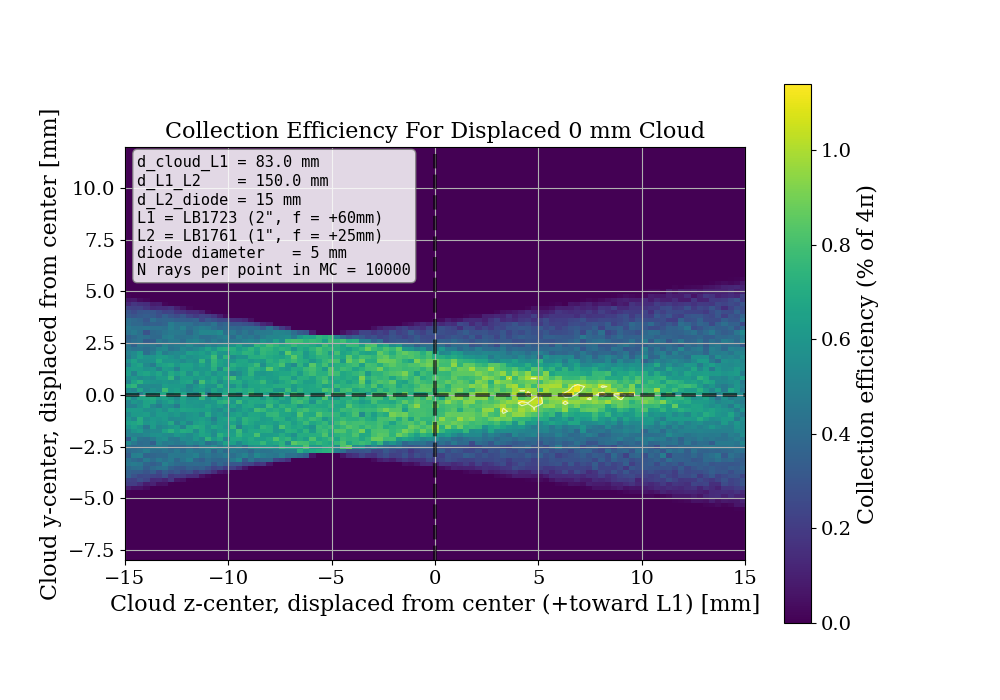

In [25]:
#vectorized thin lens. Fast!
# --- Cloud + scan ---
cloud_d = 0                          # mm, treated as a disk in (y,z)
R = cloud_d / 2
N = 10000                               # rays per grid cell
y_grid = np.linspace(-8, 12, 101)
z_grid = np.linspace(-15, 15, 101)        # +z = toward L1

eff = np.zeros((len(z_grid), len(y_grid)))

# --- System parameters (thin-lens equivalents of your ThickLenses) ---
f_L1, D_L1 = 60.0, 50.8
f_L2, D_L2 = 25.4, 25.4

def trace_batch(y0, theta0, d1):
    """Vectorized ABCD through viewport -> L1 -> L2 -> diode. Returns survival mask."""
    # propagate to viewport (just before L1)
    y = y0 + theta0 * d1
    ok = np.abs(y) <= D_viewport/2
    # propagate the rest of the way to L1 (zero distance — viewport sits at L1)
    ok &= np.abs(y) <= D_L1/2
    # bend at L1
    theta = theta0 - y/f_L1
    # propagate to L2
    y = y + theta * d_L1_L2
    ok &= np.abs(y) <= D_L2/2
    # bend at L2
    theta = theta - y/f_L2
    # propagate to diode
    y = y + theta * d_L2_diode
    ok &= np.abs(y) <= diameter_diode/2
    return ok

# --- MC loop ---
for i, zc in enumerate(z_grid):
    for j, yc in enumerate(y_grid):
        r   = R * np.sqrt(np.random.rand(N))
        phi = 2*np.pi * np.random.rand(N)
        dy, dz = r*np.cos(phi), r*np.sin(phi)
        theta = np.arccos(np.random.rand(N)) * np.random.choice([-1, 1], N)

        # cloud z-shift folds into the cloud→L1 distance
        d1 = d_cloud_L1 - (zc + dz)
        y0 = yc + dy
        survived = trace_batch(y0, theta, d1)
        eff[i, j] = survived.sum() / N / 2.0 * 100

    info = (
    f"d_cloud_L1 = {d_cloud_L1} mm\n"
    f"d_L1_L2    = {d_L1_L2} mm\n"
    f"d_L2_diode = {d_L2_diode} mm\n"
    f'L1 = LB1723 (2", f = +60mm)\n'
    f'L2 = LB1761 (1", f = +25mm)\n'
    f"diode diameter   = {diameter_diode} mm\n"
    f"N rays per point in MC = {N}"
)


fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(eff.T,
               extent=[z_grid[0], z_grid[-1], y_grid[0], y_grid[-1]],
               origin='lower', aspect='equal', cmap='viridis')
ax.set_xlabel('Cloud z-center, displaced from center (+toward L1) [mm]')
ax.set_ylabel('Cloud y-center, displaced from center [mm]')
plt.colorbar(im, ax=ax, label='Collection efficiency (% of 4π)')

Z, Y = np.meshgrid(z_grid, y_grid)
cs = ax.contour(Z, Y, eff.T, levels=[1, 1.2, 1.4, 2.0],
                colors='white', linewidths=0.8, alpha=0.7)
ax.clabel(cs, inline=True, fontsize=10, fmt='%.1f')


ax.set_title(f'Collection Efficiency For Displaced {cloud_d} mm Cloud')

ax.text(0.02, 0.98, info, transform=ax.transAxes,
        va='top', ha='left', family='monospace', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='white',
                  alpha=0.85, edgecolor='gray'))
ax.axhline(0, color='black', linewidth=2.8, alpha=.6, linestyle = '--')
ax.axvline(0, color='black', linewidth=2.8, alpha=.6, linestyle = '--')
plt.show()
plt.tight_layout()

In [ ]:
# --- Cloud + scan ---
cloud_d = 0                          # mm, treated as a disk in (y,z)
R = cloud_d / 2
N = 80                               # rays per grid cell
y_grid = np.linspace(-15, 15, 36)
z_grid = np.linspace(-10, 25, 36)        # +z = toward L1

eff = np.zeros((len(z_grid), len(y_grid)))

for i, zc in enumerate(z_grid):
    for j, yc in enumerate(y_grid):
        # atom positions, uniform inside a disk of radius R
        r   = R * np.sqrt(np.random.rand(N))
        phi = 2*np.pi * np.random.rand(N)
        dy, dz = r*np.cos(phi), r*np.sin(phi)

        # 3D-isotropic emission, forward hemisphere; divide by 2 at end for full 4π
        theta = np.arccos(np.random.rand(N)) * np.random.choice([-1, 1], N)

        # absorb (yc+dy, zc+dz) into effective y at z=0
        y_eff = (yc + dy) - theta * (zc + dz)

        n_pass = sum(
            not path.traceThrough(Ray(y=y_eff[k], theta=theta[k])).isBlocked
            for k in range(N)
        )
        eff[i, j] = n_pass / N / 2.0 * 100   # 4π-normalized

info = (
    f"d_cloud_L1 = {d_cloud_L1} mm\n"
    f"d_L1_L2    = {d_L1_L2} mm\n"
    f"d_L2_diode = {d_L2_diode} mm\n"
    f'L1 = LB1723 (2", f = +t60mm)\n'
    f'L2 = LB1761 (1", f = +25mm)\n'
    f"diode diameter   = {diameter_diode} mm\n"
    f"N rays per point in MC = {N}"
)


fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(eff.T,
               extent=[z_grid[0], z_grid[-1], y_grid[0], y_grid[-1]],
               origin='lower', aspect='equal', cmap='viridis')
ax.set_xlabel('Cloud z-center, displaced from center (+toward L1) [mm]')
ax.set_ylabel('Cloud y-center, displaced from center [mm]')
plt.colorbar(im, ax=ax, label='Collection efficiency (% of 4π)')

Z, Y = np.meshgrid(z_grid, y_grid)
cs = ax.contour(Z, Y, eff.T, levels=[1, 2.0],
                colors='white', linewidths=0.8, alpha=0.7)
ax.clabel(cs, inline=True, fontsize=10, fmt='%.1f')


ax.set_title(f'Collection Efficiency For Displaced Point')

ax.text(0.02, 0.98, info, transform=ax.transAxes,
        va='top', ha='left', family='monospace', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='white',
                  alpha=0.85, edgecolor='gray'))
plt.show()
plt.tight_layout()

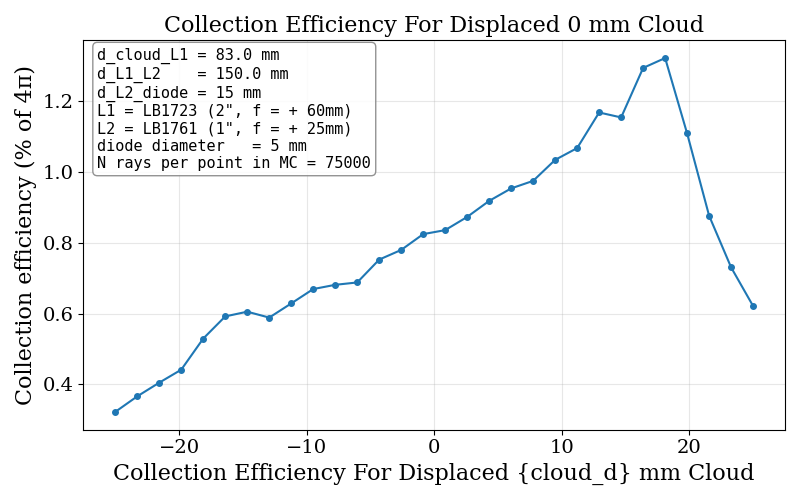

In [16]:
#1D along Z axis
# --- Cloud + scan ---
cloud_d = 0                          # mm, treated as a disk in (y,z)
R = cloud_d / 2
N = 75000                              # rays per z point
z_grid = np.linspace(-25, 25, 30)      # +z = toward L1

eff = np.zeros(len(z_grid))

for i, zc in enumerate(z_grid):
    # atom positions, uniform inside a disk of radius R
    r   = R * np.sqrt(np.random.rand(N))
    phi = 2*np.pi * np.random.rand(N)
    dy, dz = r*np.cos(phi), r*np.sin(phi)

    # 3D-isotropic emission, forward hemisphere; divide by 2 at end for full 4π
    theta = np.arccos(np.random.rand(N)) * np.random.choice([-1, 1], N)

    # absorb (dy, zc+dz) into effective y at z=0
    y_eff = dy - theta * (zc + dz)

    n_pass = sum(
        not path.traceThrough(Ray(y=y_eff[k], theta=theta[k])).isBlocked
        for k in range(N)
    )
    eff[i] = n_pass / N / 2.0 * 100    # 4π-normalized, percent

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z_grid, eff, marker='o', markersize=4)
ax.set_xlabel('Collection Efficiency For Displaced {cloud_d} mm Cloud')
ax.set_ylabel('Collection efficiency (% of 4π)')
ax.set_title(f'Collection Efficiency For Displaced {cloud_d} mm Cloud')
ax.grid(True, alpha=0.3)

info = (
    f"d_cloud_L1 = {d_cloud_L1} mm\n"
    f"d_L1_L2    = {d_L1_L2} mm\n"
    f"d_L2_diode = {d_L2_diode} mm\n"
    f'L1 = LB1723 (2", f = +60mm)\n'
    f'L2 = LB1761 (1", f = +25mm)\n'
    f"diode diameter   = {diameter_diode} mm\n"
    f"N rays per point in MC = {N}"
)

ax.text(0.02, 0.98, info, transform=ax.transAxes,
        va='top', ha='left', family='monospace', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='white',
                  alpha=0.85, edgecolor='gray'))

plt.tight_layout()
plt.show()